#Samikshhya Gurung(2417750)
#Worksheet 7

## Step 1: Load, pre- process and add a Noise to the Dataset:

1.1 Tasks to Do:
1. Load the MNIST dataset using keras.
2. Normalize the images to be in the range [0- 1] {rescaling}.
3. Reshape the images to be 28×28×1.
4. Add a Gaussian noise to the images with noise factor of 0.5.
5. Clip the noisy images to ensure all pixel values are between 0 and 1.
6. Visualize the Input image and Noise added image

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


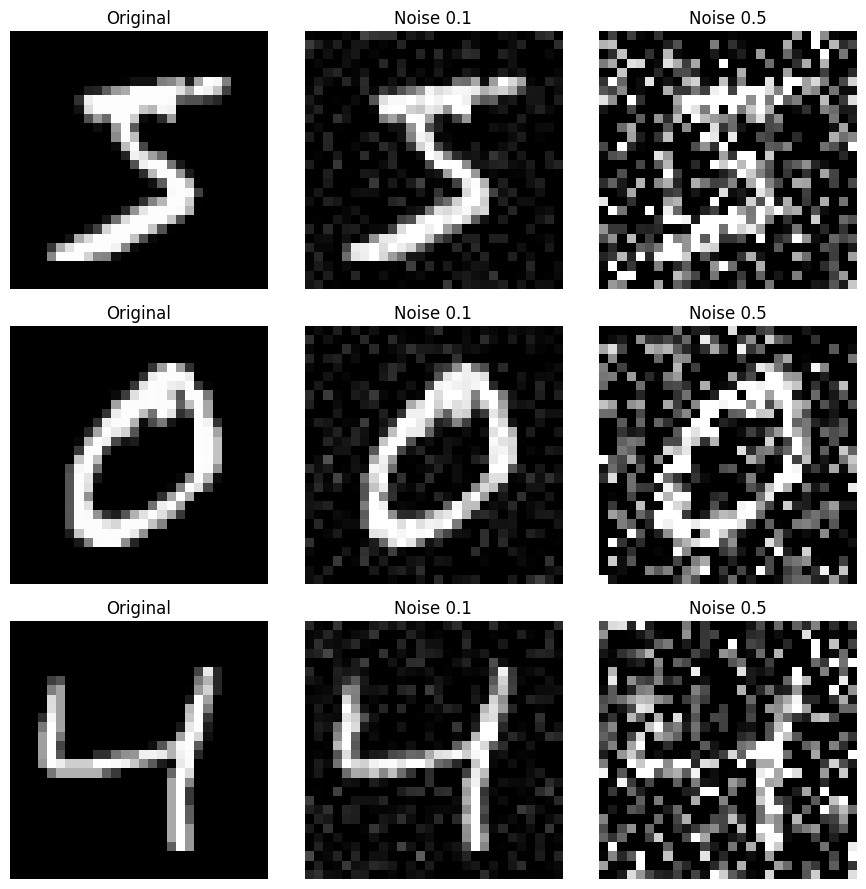

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5

x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)

x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

# Visualize in a 3 x 3 grid
n = 3  # number of images to show
plt.figure(figsize=(9, 9))
for i in range(n):
    # Original image
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Low noise image
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')

    # High noise image
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')

plt.tight_layout()
plt.show()


##Step 2: Build the Convolutional Denoising Autoencoder Model:
2.1 Tasks to Do:

• Encoder:

– Convolutional Layers + ReLU activation.

– Maxpooling to down-sample the features.



In [12]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [13]:
def build_encoder(input_shape=(28, 28, 1)):
    """
    Builds the encoder part of the convolutional autoencoder.
    Parameters:
        input_shape (tuple): Shape of the input image. Default is (28, 28, 1) for MNIST.
    Returns:
        input_img (Keras Input): Input layer of the model.
        encoded (Keras Tensor): Encoded representation after convolution and pooling.
    """
    input_img = Input(shape=input_shape, name="input")
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
    return input_img, encoded


• Decoder:

– Convolutional layers + ReLU activation.

– Upsampling to upsample the feature maps.

– Final Layer with sigmoid activation to keep output pixels in range [0,1].

In [14]:
def build_decoder(encoded_input):
    """
    Builds the decoder part of the convolutional autoencoder.
    Parameters:
        encoded_input (Keras Tensor): The output from the encoder.
    Returns:
        decoded (Keras Tensor): The reconstructed output after upsampling and convolution.
    """
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
    return decoded


•CompleteAutoencoder:

In [15]:
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_autoencoder():
    """
    Constructs and compiles the full convolutional autoencoder
    by connecting encoder and decoder.
    Returns:
        autoencoder (Keras Model): Compiled autoencoder model.
    """
    # Build encoder
    input_img, encoded_output = build_encoder()

    # Build decoder
    decoded_output = build_decoder(encoded_output)

    # Connect encoder and decoder
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")

    # Compile the model
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

    return autoencoder


•CompiletheModel:

In [16]:
autoencoder = build_autoencoder()
autoencoder.summary()


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

##Step 3: Train the Autoencoder:
3.1 Tasks to Do:

• Train the autoencoder using the noisy images as input and the clean images as the target.

• Monitor the training and validation loss during training

In [17]:
# Build the autoencoder from previous steps
autoencoder = build_autoencoder()
# Train with noisy input and clean target
history = autoencoder.fit(
x_train_noisy_high, x_train,
epochs=10,
batch_size=128,
shuffle=True,
validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 210s 440ms/step - loss: 0.1536 - val_loss: 0.1116
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 428ms/step - loss: 0.1085 - val_loss: 0.1046
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 205s 438ms/step - loss: 0.1035 - val_loss: 0.1013
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 254s 421ms/step - loss: 0.1011 - val_loss: 0.0993
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 203s 423ms/step - loss: 0.0994 - val_loss: 0.0981
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 204s 434ms/step - loss: 0.0983 - val_loss: 0.0974
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 259s 429ms/step - loss: 0.0975 - val_loss: 0.0965
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 425ms/step - loss: 0.0967 - val_loss: 0.0960
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 426ms/step - loss: 0.0961 - val_loss: 0.0954
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 203s 432ms/step - loss: 0.0956 - val_loss: 0.0948


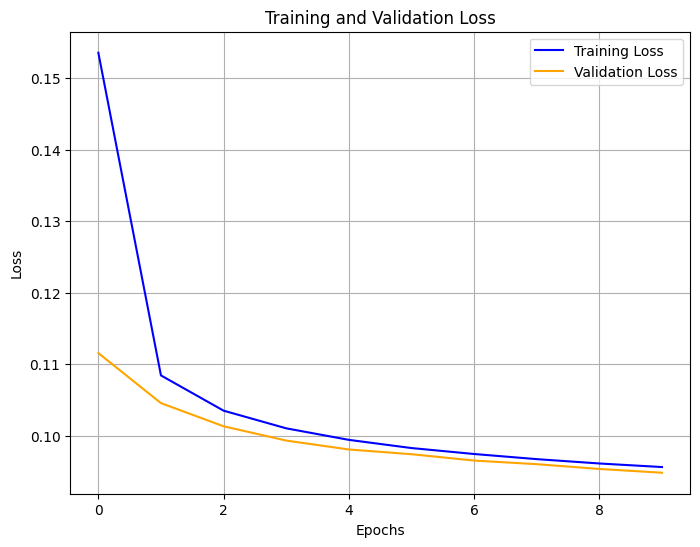

In [26]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


##Step 4: Evaluate the Autoencoder:
4.1 Tasks to Do:

• Use the trained autoencoder to predict the denoised images from the noisy test images.

• Display the original noisy images, the denoised images, and the clean images.

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step


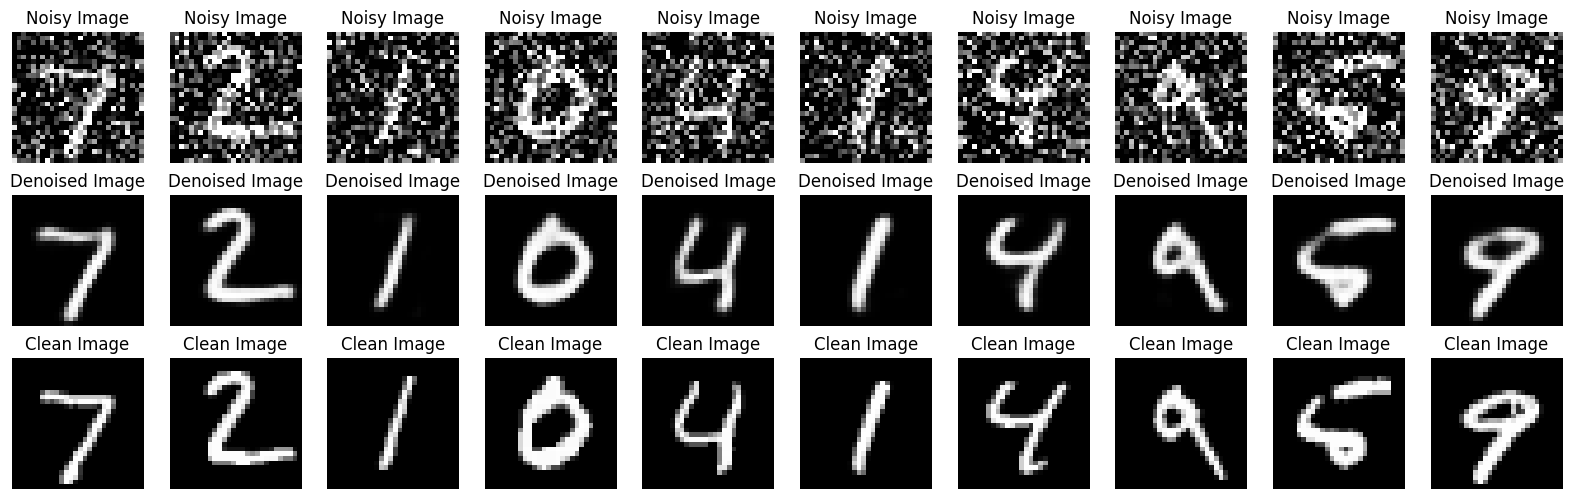

In [27]:
import matplotlib.pyplot as plt

# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)

# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
        # Plot noisy images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image")
        plt.axis('off')

        # Plot denoised images
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image")
        plt.axis('off')

        # Plot clean images
        plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image")
        plt.axis('off')

    plt.show()

# Display the first 10 images
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)


##4 Exercise: Build a Denoising Convolutional Autoencoder
4.1 Instructions:

1. Dataset Preparation and Preprocessing:

  • Load the Devnagari dataset using PIL.

  • Normalize the images to the range [0, 1].

  • Reshape the images to include a channel dimension for Keras Compatibility.

  • Split the dataset into training and validation sets.

  • Add noise to the images for denoising purposes (Gaussian noise or salt-and-pepper noise)

In [34]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical

import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and Machine Learning/week7/devnagari digit.zip"
extract_path = "/content/devnagari"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done!")

Extraction done!


In [35]:
base_path = "/content/devnagari/DevanagariHandwrittenDigitDataset"

train_dir = os.path.join(base_path, "Train")
test_dir = os.path.join(base_path, "Test")

In [46]:
import numpy as np
import os
from PIL import Image
from sklearn.model_selection import train_test_split

# Load images from a folder and its subfolders
def load_images_from_folder(base_folder, img_size=(32,32)):
    images = []
    # Iterate through all subdirectories in the base_folder
    for root, dirs, files in os.walk(base_folder):
        for filename in files:
            if filename.endswith(".png") or filename.endswith(".jpg"):
                img_path = os.path.join(root, filename)
                img = Image.open(img_path).convert('L')  # grayscale
                img = img.resize(img_size)  # resize to 32x32
                images.append(np.array(img))
    return np.array(images)

# Load train and test sets
x_train = load_images_from_folder(train_dir)
x_test = load_images_from_folder(test_dir)

# Normalize to [0,1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape to include channel dimension
x_train = np.expand_dims(x_train, -1)  # shape: (num_samples, 32, 32, 1)
x_test = np.expand_dims(x_test, -1)

# Optional: create validation split from training
x_train, x_val = train_test_split(x_train, test_size=0.1, random_state=42)

# Add Gaussian noise
noise_factor = 0.5
x_train_noisy = np.clip(x_train + noise_factor * np.random.normal(size=x_train.shape), 0., 1.)
x_val_noisy   = np.clip(x_val   + noise_factor * np.random.normal(size=x_val.shape),   0., 1.)
x_test_noisy  = np.clip(x_test  + noise_factor * np.random.normal(size=x_test.shape),  0., 1.)

# Add Salt-and-Pepper noise
def add_salt_pepper_noise(images, amount=0.05):
    noisy = images.copy()
    num_salt = np.ceil(amount * images.size * 0.5)
    num_pepper = np.ceil(amount * images.size * 0.5)

    # Generate coordinates for spatial dimensions only (exclude channel dimension)
    img_shape_spatial = images.shape[:-1]  # Exclude the last dimension (channels)

    # Salt
    coords_salt = [np.random.randint(0, dim, int(num_salt)) for dim in img_shape_spatial]
    # Add a channel coordinate, always 0 for grayscale
    coords_salt.append(np.zeros(int(num_salt), dtype=int))
    noisy[tuple(coords_salt)] = 1

    # Pepper
    coords_pepper = [np.random.randint(0, dim, int(num_pepper)) for dim in img_shape_spatial]
    # Add a channel coordinate, always 0 for grayscale
    coords_pepper.append(np.zeros(int(num_pepper), dtype=int))
    noisy[tuple(coords_pepper)] = 0

    return noisy

x_train_sp = add_salt_pepper_noise(x_train, amount=0.05)
x_val_sp   = add_salt_pepper_noise(x_val, amount=0.05)
x_test_sp  = add_salt_pepper_noise(x_test, amount=0.05)

print("Train shape:", x_train.shape)
print("Validation shape:", x_val.shape)
print("Test shape:", x_test.shape)

Train shape: (15300, 32, 32, 1)
Validation shape: (1700, 32, 32, 1)
Test shape: (3000, 32, 32, 1)


##2. Build the Denoising Convolutional Autoencoder:

Build a convolutional autoencoder with at least 4 layers. The model should have an encoder to compress the input and a decoder to reconstruct the original image.

• Use convolutional layers for the encoder and decoder.

• Use ReLU activations for hidden layers and sigmoid for the output layer

In [47]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_autoencoder(input_shape=(32, 32, 1)):
    input_img = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2,2), padding='same')(x)

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2,2), padding='same')(x)

    # Decoder
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2,2))(x)

    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2,2))(x)

    decoded = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

##3. Train the Denoising Autoencoder:
Train the model with the noisy images as inputs and the original images as targets. Monitor the training
process by plotting the loss curves

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 74s 605ms/step - loss: 0.1712 - val_loss: 0.1643
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 69s 574ms/step - loss: 0.1636 - val_loss: 0.1601
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 72s 597ms/step - loss: 0.1595 - val_loss: 0.1577
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 76s 626ms/step - loss: 0.1573 - val_loss: 0.1555
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 71s 593ms/step - loss: 0.1553 - val_loss: 0.1553
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 83s 599ms/step - loss: 0.1536 - val_loss: 0.1526
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 81s 593ms/step - loss: 0.1525 - val_loss: 0.1517
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 72s 597ms/step - loss: 0.1512 - val_loss: 0.1504
Epoch 9/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 80s 576ms/step - loss: 0.1504 - val_loss: 0.1499
Epoch 10/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 81s 572ms/step - loss: 0.1497 - val_loss: 0.1489


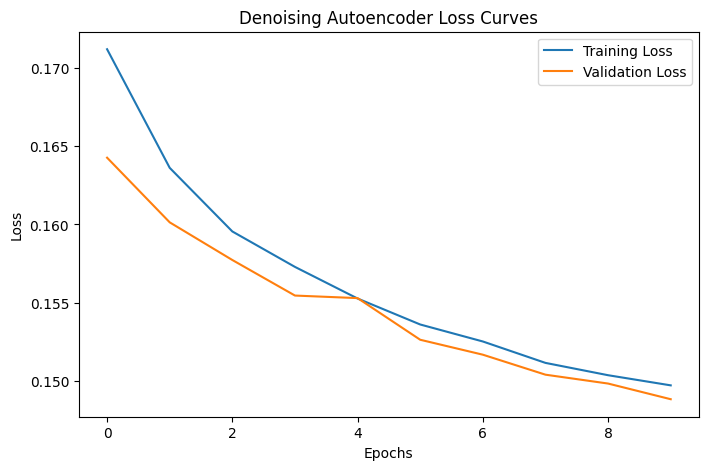

In [49]:
# Train the denoising autoencoder
history = autoencoder.fit(
    x_train_noisy, x_train,          # noisy input → clean target
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy, x_val)
)

# Plot training and validation loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Denoising Autoencoder Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


##4. Evaluate and Visualize the Results:

Evaluate the performance of the denoising autoencoder by visualizing a few noisy images, the denoised
images generated by the model, and the original clean images

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step


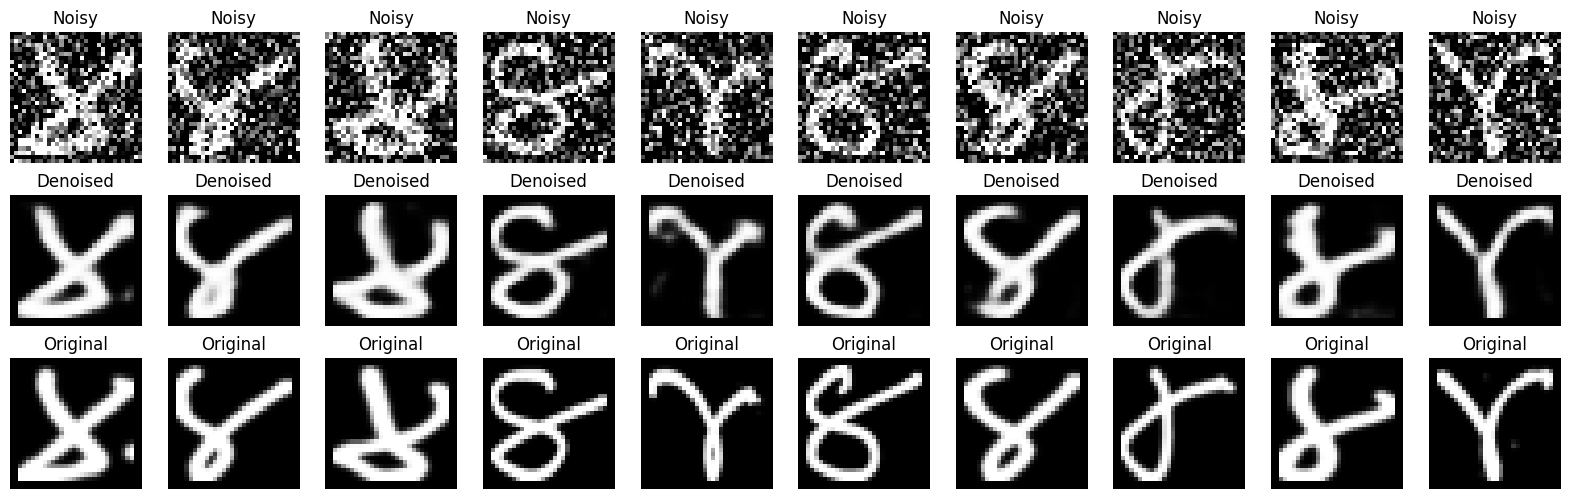

In [50]:
import matplotlib.pyplot as plt

# Generate reconstructions from noisy test images
decoded_imgs = autoencoder.predict(x_test_noisy[:10])

# Plot noisy → reconstructed → clean
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Noisy input
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(32,32), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised output
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(32,32), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    # Original clean
    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(x_test[i].reshape(32,32), cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.show()
